In [8]:
#Bibliotheken laden
import pandas as pd
import random
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter, defaultdict
import nltk
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
# CSV laden
print("Reading CSV...")
df_articles = pd.read_csv(
    "artikel_korpus_fin.csv",
    sep=";",                    
    encoding="latin1",
    header=0,
    on_bad_lines="skip",
    keep_default_na=False
)
print("✓ CSV loaded.")
print("Columns detected:", list(df_articles.columns))

Reading CSV...
✓ CSV loaded.
Columns detected: ['ID', 'Titel', 'Zeitung', 'Datum', 'Section', 'Byline', 'Subject', 'Industry', 'Person', 'Geographic', 'Load-Date', 'Body-TXT-Datei', 'Text', 'Datum_standardisiert']


In [10]:
#  Datum parsen & Jahr extrahieren
df_articles['Datum_standardisiert'] = pd.to_datetime(
    df_articles['Datum_standardisiert'], format="%Y-%m-%d", errors="coerce"
)
df_articles['Jahr'] = df_articles['Datum_standardisiert'].dt.year

def jahr_zu_periode(jahr, breite=5):
    if pd.isna(jahr):
        return None
    return (jahr // breite) * breite  

df_articles['Periode'] = df_articles['Jahr'].apply(jahr_zu_periode)


In [11]:
# Texte vorbereiten
nltk.download('punkt')
stop_words = set(stopwords.words('english'))
texte_pro_periode = defaultdict(list)

for _, row in df_articles.iterrows():
    if not isinstance(row['Text'], str):
        continue
    tokens = [
        w for w in word_tokenize(row['Text'].lower())
        if w.isalpha() and w not in stop_words
    ]
    if tokens:
        texte_pro_periode[row['Periode']].append(tokens)

print("Texte pro Periode erstellt.")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\s-kup\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Texte pro Periode erstellt.


In [12]:
#  4. Word2Vec trainieren & Similarities berechnen 
wortpaare = [
    ("atom", "energy"),
    ("atom", "bomb"),
    ("nuclear", "energy"),
    ("nuclear", "bomb")
]

similarity_scores = []

for periode, texte in texte_pro_periode.items():
    if len(texte) < 100:
        continue

    print(f"\nTrainiere Word2Vec für {periode}–{periode+4} ({len(texte)} Artikel)")
    model = Word2Vec(
        sentences=texte,
        vector_size=100,
        window=5,
        min_count=2,
        sg=1,
        workers=4,
        epochs=50
    )
    model.save(f"word2vec_{periode}_{periode+4}.model")

    periode_scores = {"periode": periode}
    for w1, w2 in wortpaare:
        if w1 in model.wv and w2 in model.wv:
            score = model.wv.similarity(w1, w2)
            periode_scores[f"{w1}–{w2}"] = score
        else:
            periode_scores[f"{w1}–{w2}"] = None
    similarity_scores.append(periode_scores)

df_similarity = pd.DataFrame(similarity_scores).sort_values("periode")
print("\nSimilarity-Scores:")
print(df_similarity)



Trainiere Word2Vec für 2005.0–2009.0 (1273 Artikel)

Trainiere Word2Vec für 1980.0–1984.0 (1865 Artikel)

Trainiere Word2Vec für 1985.0–1989.0 (1552 Artikel)

Trainiere Word2Vec für 1990.0–1994.0 (1333 Artikel)

Trainiere Word2Vec für 2020.0–2024.0 (1246 Artikel)

Trainiere Word2Vec für 2015.0–2019.0 (1153 Artikel)

Trainiere Word2Vec für 2010.0–2014.0 (1047 Artikel)

Trainiere Word2Vec für 1995.0–1999.0 (995 Artikel)

Trainiere Word2Vec für 2000.0–2004.0 (1394 Artikel)

Similarity-Scores:
   periode  atom–energy  atom–bomb  nuclear–energy  nuclear–bomb
1   1980.0     0.304901   0.594821        0.468808      0.444111
2   1985.0     0.285916   0.509571        0.474971      0.481348
3   1990.0     0.365471   0.499984        0.486453      0.552298
7   1995.0     0.295198   0.536677        0.518288      0.481774
8   2000.0     0.323555   0.571687        0.547110      0.489721
0   2005.0     0.309847   0.687987        0.558793      0.544371
6   2010.0     0.263462   0.647748        0.55092

In [17]:
# 5. Bootstrapping für Stabilität 
def bootstrap_neighbors(texte, zielwort, n_runs=5, sample_frac=0.8, topn=10):
    nachbarn_counter = Counter()
    for i in range(n_runs):
        sample_size = max(1, int(len(texte) * sample_frac))
        sample = random.sample(texte, sample_size)
        model = Word2Vec(
            sentences=sample,
            vector_size=100,
            window=5,
            min_count=2,
            sg=1,
            workers=4, 
            epochs= 20
        )
        if zielwort in model.wv:
            ähnlich = model.wv.most_similar(zielwort, topn=topn)
            for w, score in ähnlich:
                nachbarn_counter[w] += 1
    return nachbarn_counter

bootstrap_results = defaultdict(dict)
zielwörter = ["nuclear", "atom"]

for periode, texte in texte_pro_periode.items():
    if len(texte) < 200:
        continue
    for zielwort in zielwörter:
        counter = bootstrap_neighbors(texte, zielwort, n_runs=10, sample_frac=0.8, topn=10)
        for wort, count in counter.most_common(10):
            bootstrap_results[(zielwort, wort)][periode] = count / 10  

rows = []
for (zielwort, wort), perioden_counts in bootstrap_results.items():
    for periode, stabilität in perioden_counts.items():
        rows.append({
            "Periode": f"{int(periode)}–{int(periode+4)}",
            "Zielwort": zielwort,
            "Nachbar": wort,
            "Stabilität": stabilität
        })

df_bootstrap = pd.DataFrame(rows)
print("\nBootstrap-Ergebnisse:")
print(df_bootstrap.head(20))



Bootstrap-Ergebnisse:
      Periode Zielwort          Nachbar  Stabilität
0   2005–2009  nuclear       dismantles         0.9
1   1990–1994  nuclear       dismantles         1.0
2   2005–2009  nuclear        weaponize         0.5
3   2005–2009  nuclear            guise         0.5
4   2005–2009  nuclear         scrapped         0.5
5   2005–2009  nuclear         readmits         0.5
6   2005–2009  nuclear      reactivated         0.4
7   2005–2009  nuclear          weapons         0.4
8   1985–1989  nuclear          weapons         0.7
9   1990–1994  nuclear          weapons         1.0
10  2015–2019  nuclear          weapons         0.6
11  1995–1999  nuclear          weapons         1.0
12  2000–2004  nuclear          weapons         1.0
13  2005–2009  nuclear         classify         0.4
14  2005–2009  nuclear  infrastructures         0.4
15  2005–2009  nuclear     experimented         0.4
16  2005–2009     atom             bomb         1.0
17  1980–1984     atom             bomb  

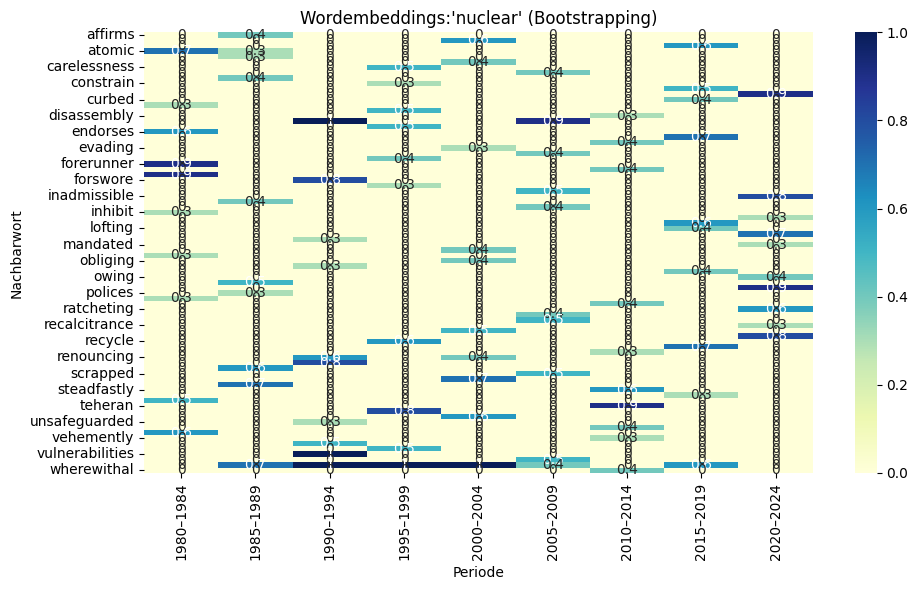

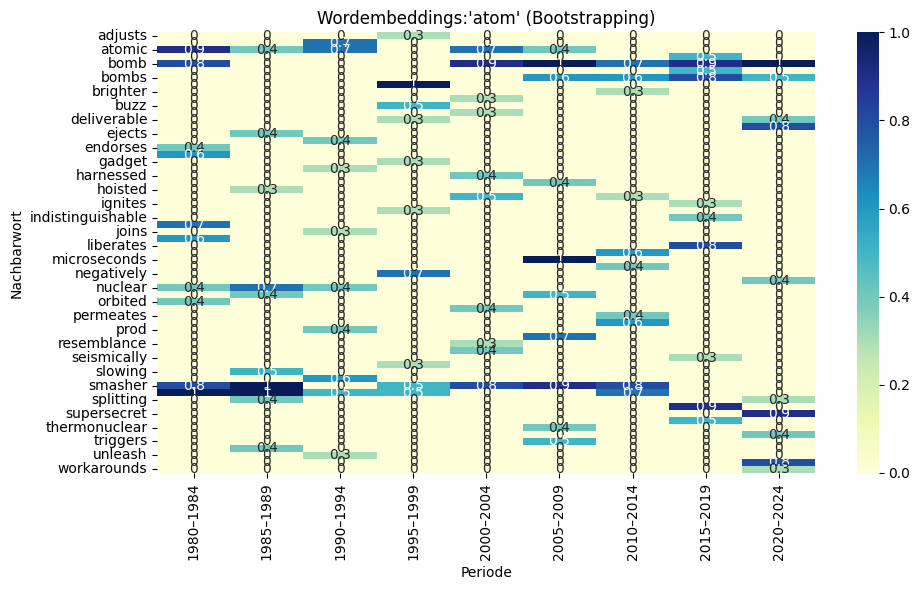

In [18]:
# 6. Visualisierung 
for zielwort in zielwörter:
    df_pivot = df_bootstrap[df_bootstrap["Zielwort"] == zielwort].pivot(
        index="Nachbar", columns="Periode", values="Stabilität"
    ).fillna(0)

    plt.figure(figsize=(10, 6))
    sns.heatmap(df_pivot, annot=True, cmap="YlGnBu", cbar=True)
    plt.title(f"Wordembeddings:'{zielwort}' (Bootstrapping)")
    plt.ylabel("Nachbarwort")
    plt.xlabel("Periode")
    plt.tight_layout()
    filename = f"Wordembeddings_{zielwort}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()